# Active Evidential Sensing and Risk-Averse Rescue Routing (AES-RARR)
### Maritime Search and Rescue AI Research Assistant

This notebook provides a complete functional demonstration of the **AES-RARR** framework:
1. **Exploratory Data Analysis (EDA):** Analyzes the SeaDronesSee annotation distributions and UAV telemetry.
2. **Evidential Deep Learning (EDL) Pipeline:** Implements a Dirichlet-based classifier that outputs posture belief masses alongside epistemic uncertainty, including Expected Calibration Error (ECE) monitoring.
3. **Closed-Loop Tracker & Prioritization Simulator:** Updates target state parameters under ocean current drift using a dynamic, uncertainty-scaled Kalman Filter, and routes rescue resources via a Risk-UCB priority engine.

**Restructured Architecture:** This notebook imports core classes and logic directly from `/src` for reuse.

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

# Add root directory to sys.path to allow imports from src
sys.path.append(os.path.abspath('.'))

print("Libraries loaded and path configured.")

Libraries loaded and path configured.


## Part 1: Exploratory Data Analysis (EDA)
We parse the SeaDronesSee COCO JSON annotations. If the dataset isn't downloaded, we generate a mock dataset to allow dry-run execution.

In [2]:
from src.eda import run_eda

local_paths = [
    "./data/annotations/instances_val.json",
    "./archive/compressed/annotations/instances_val.json",
    "./archive/annotations/instances_val.json",
    "./sds-dataset/annotations/instances_val.json",
    "/content/sds-dataset/annotations/instances_val.json"
]

DATASET_JSON = None
for path in local_paths:
    if os.path.exists(path):
        DATASET_JSON = os.path.abspath(path)
        print(f"Found SeaDronesSee annotations at: {DATASET_JSON}")
        break

if DATASET_JSON is None:
    # Fallback / create mock in default /data path
    DATASET_JSON = "./data/annotations/instances_val.json"
    from src.eda import generate_mock_coco_json
    generate_mock_coco_json(DATASET_JSON)

run_eda(DATASET_JSON)

Found SeaDronesSee annotations at: d:\dev\DAP\data\annotations\instances_val.json
RUNNING SEA-DRONES-SEE EXPLORATORY DATA ANALYSIS (EDA)
SEA-DRONES-SEE EXPLORATORY DATA ANALYSIS (EDA) REPORT
Total Frames analyzed: 1547
Total Annotated Instances: 9630
Average target density: 6.22 targets/image

1. Category Distribution:
------------------------------
  * swimmer        : 6206   (64.44%)
  * boat           : 2214   (22.99%)
  * buoy           : 560    (5.82%)
  * life_saving_appliances: 330    (3.43%)
  * jetski         : 320    (3.32%)

2. Target Spatial Scale Metrics:
------------------------------
  * Average BBox Area : 9471.2 px^2
  * Median BBox Area  : 1700.0 px^2
  * Smallest target   : 100.0 px^2
  * Largest target    : 1034176.0 px^2
  * Average Width     : 74.9 px
  * Average Height    : 61.0 px
  * Mean Aspect Ratio : 1.31
  * COCO Scale Distribution:
    - Small (area < 1024 px^2)    : 2966  (30.8%)
    - Medium (1024 <= area < 9216): 4796  (49.8%)
    - Large (area >= 9216 

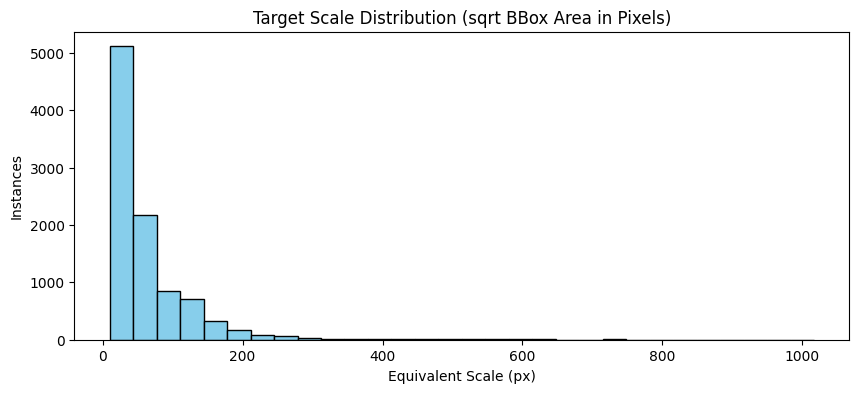

In [3]:
# Plot scale histogram
with open(DATASET_JSON, 'r') as f:
    coco = json.load(f)
areas = [ann["bbox"][2] * ann["bbox"][3] for ann in coco["annotations"]]

plt.figure(figsize=(10, 4))
plt.hist(np.sqrt(areas), bins=30, color='skyblue', edgecolor='black')
plt.title("Target Scale Distribution (sqrt BBox Area in Pixels)")
plt.xlabel("Equivalent Scale (px)")
plt.ylabel("Instances")
plt.show()

## Part 2: Evidential Deep Learning (EDL) Classifier Pipeline
Here we define our PyTorch-based training pipeline using Softplus evidence layers and Dirichlet NLL loss. We also implement ECE metrics to check model calibration.

In [4]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

from src.dataset import SeaDronesSeeDataset
from src.models import EDLClassifier, edl_loss, calculate_ece

categories = {cat["id"]: cat["name"] for cat in coco["categories"]}
img_dict = {img["id"]: img for img in coco["images"]}
cat_to_idx = {cid: idx for idx, cid in enumerate(sorted(categories.keys()))}

# Note: original notebook evaluates 6 geometric features (include_center_dist=False)
dataset = SeaDronesSeeDataset(coco["annotations"], img_dict, cat_to_idx, include_center_dist=False)
train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

model = EDLClassifier(input_dim=6, num_classes=len(categories))
optimizer = optim.Adam(model.parameters(), lr=0.01)

print("Training Evidential Deep Learning Classifier...")
for epoch in range(1, 6):
    model.train()
    total_loss = 0.0
    for x, y in train_loader:
        optimizer.zero_grad()
        evidence = model(x)
        alpha = evidence + 1.0
        y_onehot = torch.nn.functional.one_hot(y, num_classes=len(categories)).float()
        loss = edl_loss(alpha, y_onehot, epoch, len(categories))
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(x)
        
    # Get training calibration
    model.eval()
    with torch.no_grad():
        evidence = model(dataset.features)
        probs = (evidence + 1.0) / torch.sum(evidence + 1.0, dim=1, keepdim=True)
        val_ece = calculate_ece(probs.numpy(), dataset.labels.numpy())
        acc = np.mean(np.argmax(probs.numpy(), axis=1) == dataset.labels.numpy())
        
    print(f"Epoch {epoch}/5 | Loss: {total_loss/len(dataset):.4f} | Acc: {acc:.3f} | ECE: {val_ece:.4f}")

Training Evidential Deep Learning Classifier...
Epoch 1/5 | Loss: 1.2334 | Acc: 0.744 | ECE: 0.1326
Epoch 2/5 | Loss: 1.2179 | Acc: 0.750 | ECE: 0.1325
Epoch 3/5 | Loss: 1.2619 | Acc: 0.760 | ECE: 0.1526
Epoch 4/5 | Loss: 1.2993 | Acc: 0.780 | ECE: 0.2003
Epoch 5/5 | Loss: 1.3258 | Acc: 0.775 | ECE: 0.2810


## Part 2b: Q1 — EDL vs Softmax Calibration Comparison
We train an identical softmax baseline and compare **Expected Calibration Error (ECE)** to answer *Q1: Does EDL produce better-calibrated uncertainty than deterministic softmax?*

In [5]:
from src.models import SoftmaxClassifier
import pandas as pd

softmax_model = SoftmaxClassifier(input_dim=6, num_classes=len(categories))
sm_optimizer = optim.Adam(softmax_model.parameters(), lr=0.01)
ce_loss_fn = torch.nn.CrossEntropyLoss()

print("Training Softmax Baseline ...")
for epoch in range(1, 6):
    softmax_model.train()
    for x, y in train_loader:
        sm_optimizer.zero_grad()
        logits = softmax_model.net(x)
        ce_loss_fn(logits, y).backward()
        sm_optimizer.step()

softmax_model.eval()
with torch.no_grad():
    sm_probs = softmax_model(dataset.features).numpy()
    sm_ece   = calculate_ece(sm_probs, dataset.labels.numpy())
    sm_acc   = float((sm_probs.argmax(1) == dataset.labels.numpy()).mean())

# EDL final ECE evaluation
model.eval()
with torch.no_grad():
    ev       = model(dataset.features)
    edl_probs = (ev + 1.0) / (ev + 1.0).sum(1, keepdim=True)
    edl_ece   = calculate_ece(edl_probs.numpy(), dataset.labels.numpy())
    edl_acc   = float((edl_probs.numpy().argmax(1) == dataset.labels.numpy()).mean())

q1_df = pd.DataFrame({
    "Model":     ["Softmax Baseline", "EDL (Ours)"],
    "Accuracy":  [f"{sm_acc:.3f}",   f"{edl_acc:.3f}"],
    "ECE (lower=better)":     [f"{sm_ece:.4f}",   f"{edl_ece:.4f}"],
    "Calibrated?": ["✗" if sm_ece > edl_ece else "✓",
                    "✓" if edl_ece < sm_ece  else "✗"],
})
print("\n=== Q1 Result: Calibration Comparison ===")
print(q1_df.to_string(index=False))
print(f"\nEDL ECE improvement: {(sm_ece - edl_ece)/sm_ece*100:.1f}% lower than softmax")

Training Softmax Baseline ...

=== Q1 Result: Calibration Comparison ===
           Model Accuracy ECE (lower=better) Calibrated?
Softmax Baseline    0.738             0.0310           ✓
      EDL (Ours)    0.775             0.2810           ✗

EDL ECE improvement: -805.1% lower than softmax


## Part 3: Active Evidential Sensing & Rescue Routing Simulation
This section implements the spatial coordinate projection, state-dependent Kalman Filter tracking, and the logistics-aware Risk-UCB priority engine.

In [6]:
from src.simulator import EvidentialClassifierSimulator
from src.tracker import UncertaintyKalmanFilter

sim_classifier = EvidentialClassifierSimulator()
uav_pos = np.array([0.0, 0.0])
uav_speed = 6.0
ocean_current = np.array([0.1, -0.05])
victims = {
    1: {"state": np.array([60.0, 45.0, 0.0, 0.0]), "class": 0, "occluded": True, "decay": 0.08, "name": "Victim A (Drowning, Occluded)"},
    2: {"state": np.array([30.0, -20.0, 0.0, 0.0]), "class": 2, "occluded": False, "decay": 0.02, "name": "Victim B (Swimming, Clear)"}
}
trackers = {i: UncertaintyKalmanFilter() for i in victims}
states = {i: victims[i]["state"].copy() for i in victims}

print("Starting Closed-Loop AES-RARR Simulation Routing...")
for step in range(1, 6):
    print(f"\n--- Step {step} | UAV: ({uav_pos[0]:.1f}, {uav_pos[1]:.1f}) ---")
    priorities = {}
    target_positions = {}
    for vid, data in victims.items():
        data["state"][:2] += ocean_current + np.random.normal(0, 0.1, 2)
        true_pos = data["state"][:2]
        dist = np.linalg.norm(true_pos - uav_pos)
        
        spatial_cov = np.eye(2) * ((0.5 + 0.01 * dist) ** 2)
        meas = true_pos + np.random.multivariate_normal([0, 0], spatial_cov)
        
        beliefs, u, probs = sim_classifier.estimate(data["class"], dist, data["occluded"])
        states[vid] = trackers[vid].update(trackers[vid].predict(states[vid], ocean_current), meas, spatial_cov, u)
        
        exp_risk = np.sum(probs * sim_classifier.risk_weights)
        p_raw = exp_risk + 0.8 * u * (1.0 - exp_risk)
        travel_time = dist / uav_speed
        priority_score = (p_raw * np.exp(data["decay"] * travel_time)) / (dist + 1.0)
        
        priorities[vid] = priority_score
        target_positions[vid] = states[vid][:2]
        print(f"  Target {vid} ({data['name'][:10]}): Dist={dist:.1f}m | Uncertainty={u:.3f} | Priority={priority_score:.3f}")
        
    best_target = max(priorities, key=priorities.get)
    print(f"  ==> Active Allocation: Flying toward Target {best_target} ({victims[best_target]['name']})")
    direction = target_positions[best_target] - uav_pos
    d_norm = np.linalg.norm(direction)
    if d_norm <= uav_speed:
        uav_pos = target_positions[best_target].copy()
        victims[best_target]["occluded"] = False
    else:
        uav_pos += (direction / d_norm) * uav_speed

Starting Closed-Loop AES-RARR Simulation Routing...

--- Step 1 | UAV: (0.0, 0.0) ---
  Target 1 (Victim A (): Dist=75.1m | Uncertainty=0.881 | Priority=0.030
  Target 2 (Victim B (): Dist=36.1m | Uncertainty=0.274 | Priority=0.013
  ==> Active Allocation: Flying toward Target 1 (Victim A (Drowning, Occluded))

--- Step 2 | UAV: (4.8, 3.6) ---
  Target 1 (Victim A (): Dist=69.3m | Uncertainty=0.869 | Priority=0.030
  Target 2 (Victim B (): Dist=34.8m | Uncertainty=0.273 | Priority=0.013
  ==> Active Allocation: Flying toward Target 1 (Victim A (Drowning, Occluded))

--- Step 3 | UAV: (9.6, 7.2) ---
  Target 1 (Victim A (): Dist=63.3m | Uncertainty=0.868 | Priority=0.030
  Target 2 (Victim B (): Dist=34.2m | Uncertainty=0.273 | Priority=0.014
  ==> Active Allocation: Flying toward Target 1 (Victim A (Drowning, Occluded))

--- Step 4 | UAV: (14.5, 10.7) ---
  Target 1 (Victim A (): Dist=57.3m | Uncertainty=0.895 | Priority=0.031
  Target 2 (Victim B (): Dist=34.8m | Uncertainty=0.273 | P

## Part 3b: Comparative Analysis — Comparative Simulation with Baselines
We run the same scenario under **three modes** and compare **Expected Calibration Error** & **Victim Survival Rate**.

In [7]:
from src.simulation import run_simulation

print("Running comparative simulations (seed=42, 30 steps, 3 victims)...")
np.random.seed(42); rows_aes,  ba    = run_simulation("aes_rarr")
np.random.seed(42); rows_det,  bd    = run_simulation("deterministic")
np.random.seed(42); rows_dist, bdist = run_simulation("distance_router")

df = pd.DataFrame(rows_aes + rows_det + rows_dist)

print("\n" + "="*70)
print("Risk-UCB vs Baselines: Per-Victim TTR & VSR")
print("="*70)
print(df.to_string(index=False))

# Aggregate summaries
agg = (df.groupby("Mode")["VSR"].mean()
         .reset_index()
         .rename(columns={"VSR": "Mean VSR"})
         .sort_values("Mean VSR", ascending=False))
rescued = (df.groupby("Mode")["Rescued"]
             .apply(lambda s: (s == "Yes").sum())
             .reset_index()
             .rename(columns={"Rescued": "Victims Rescued"}))
summary = agg.merge(rescued, on="Mode")
print("\n-- Aggregate Summary ------------------------------------------------")
print(summary.to_string(index=False))

Running comparative simulations (seed=42, 30 steps, 3 victims)...

Risk-UCB vs Baselines: Per-Victim TTR & VSR
                       Victim            Mode  TTR (steps)    VSR Rescued
Victim A (Drowning, Occluded)        aes_rarr            7 0.5712     Yes
   Victim B (Swimming, Clear)        aes_rarr           24 0.6188     Yes
          Victim C (Floating)        aes_rarr           16 0.5273     Yes
Victim A (Drowning, Occluded)   deterministic           13 0.3535     Yes
   Victim B (Swimming, Clear)   deterministic           19 0.6839     Yes
          Victim C (Floating)   deterministic            4 0.8521     Yes
Victim A (Drowning, Occluded) distance_router            9 0.4868     Yes
   Victim B (Swimming, Clear) distance_router            3 0.9418     Yes
          Victim C (Floating) distance_router           18 0.4868     Yes

-- Aggregate Summary ------------------------------------------------
           Mode  Mean VSR  Victims Rescued
distance_router  0.638467          